In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

Text(0, 0.5, 'y dataset')

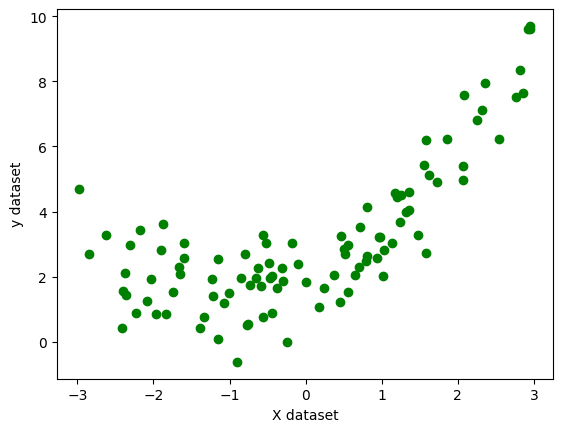

In [8]:
X=6 * np.random.rand(100,1)-3
y=0.5 * X**2 + X+2+ np.random.randn(100,1)

# quadratic equation used y=0.5x^2+1.5x+2+outliers
plt.scatter(X,y,color='g')
plt.xlabel('X dataset')
plt.ylabel('y dataset')

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
## implementing simple linear regression
from sklearn.linear_model import LinearRegression
regression_1=LinearRegression()

In [12]:
regression_1.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
from sklearn.metrics import r2_score
score=r2_score(y_test,regression_1.predict(X_test))
print(score)

-0.5141613452267133


AttributeError: module 'matplotlib.pyplot' has no attribute 'label'

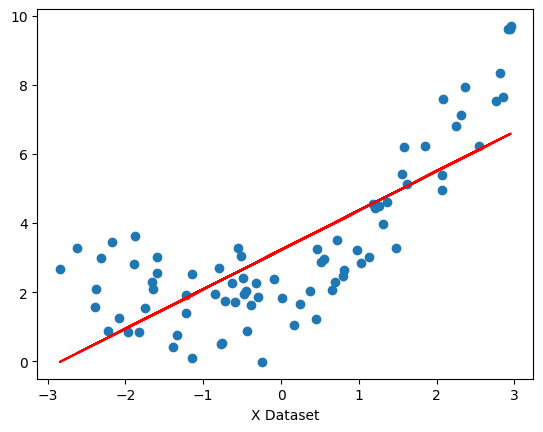

In [14]:
## lets visualize this model
plt.plot(X_train,regression_1.predict(X_train),color='r')
plt.scatter(X_train,y_train)
plt.xlabel("X Dataset")
plt.label("y")

In [15]:
# lets apply polynomial transformation
from sklearn.preprocessing import PolynomialFeatures

In [16]:
poly=PolynomialFeatures(degree=2,include_bias=False)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [17]:
X_train_poly


array([[ 1.13597504e+00,  1.29043928e+00],
       [-7.99371283e-01,  6.38994449e-01],
       [ 2.91574634e+00,  8.50157674e+00],
       [ 2.85602287e+00,  8.15686666e+00],
       [ 2.76694297e+00,  7.65597340e+00],
       [ 5.09200630e-01,  2.59285281e-01],
       [-1.64510473e+00,  2.70636957e+00],
       [-4.87835239e-01,  2.37983220e-01],
       [ 2.53767659e+00,  6.43980250e+00],
       [-2.08152857e+00,  4.33276118e+00],
       [ 2.35965173e+00,  5.56795626e+00],
       [-4.74728100e-01,  2.25366769e-01],
       [ 2.07321542e+00,  4.29822218e+00],
       [ 2.94175843e+00,  8.65394267e+00],
       [ 7.90462479e-01,  6.24830931e-01],
       [ 1.55391827e+00,  2.41466199e+00],
       [-2.84271063e+00,  8.08100370e+00],
       [ 2.95261381e+00,  8.71792833e+00],
       [ 1.03069995e+00,  1.06234239e+00],
       [-2.37552551e+00,  5.64312145e+00],
       [ 1.25831524e+00,  1.58335724e+00],
       [ 2.07126679e+00,  4.29014613e+00],
       [ 9.71467543e-01,  9.43749187e-01],
       [-5.

In [18]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly,y_train)
y_pred=regression.predict(X_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.4156688435994238


In [19]:
print(regression.coef_)

[[0.96972949 0.48229303]]


In [20]:
print(regression.intercept_)

[2.01657275]


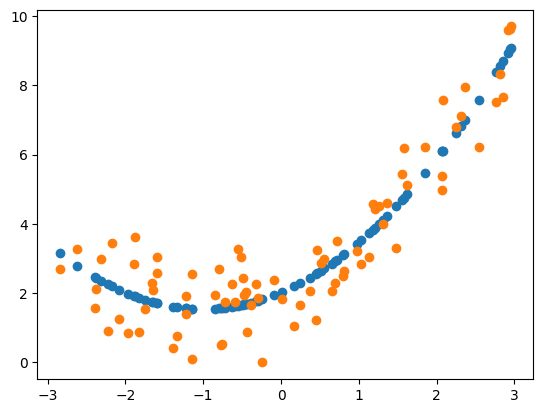

In [21]:
plt.scatter(X_train,regression.predict(X_train_poly))
plt.scatter(X_train,y_train)